In [ ]:
import pandas as pd
import numpy as np

# .apply vs .applymap => .map

df = pd.read_csv('stores_new.csv')
df.head()

,StoreCode,StoreName,StoreType,Location,OperatingCost,StaffCnt,TotalSales,TotalCustomers,AcqCostPercust,BasketSize,ProfitPercust,OwnStore,OnlinePresence,Tenure,StoreSegment,Discounted Sales,TotalCost
0,STR101,Electronics Zone,Electronincs,Delhi,21.0,60,160.0,110,3.90,2.620,16.46,0,1,4,4,152.0,450.00
1,STR102,Apparel Zone,Apparel,Delhi,21.0,60,160.0,110,3.90,2.875,17.02,0,1,4,4,152.0,450.00
2,STR103,Super Bazar,Super Market,Delhi,22.8,40,108.0,93,3.85,2.320,18.61,1,1,4,1,102.6,380.85
3,STR104,Super Market,Super Market,Delhi,21.4,60,258.0,110,3.08,3.215,19.44,1,0,3,1,245.1,360.20
4,STR105,Central Store,Super Market,Delhi,18.7,80,360.0,175,3.15,3.440,17.02,0,0,3,2,342.0,569.95


In [ ]:
df.StoreName.apply(lambda x: x.upper()) # Anonymous function
# df.StoreName.str.upper()

0     ELECTRONICS ZONE
1         APPAREL ZONE
2          SUPER BAZAR
3         SUPER MARKET
4        CENTRAL STORE
5         APPAREL ZONE
6        FASHION BAZAR
7        DIGITAL BAZAR
8     ELECTRONICS ZONE
9         APPAREL ZONE
10         SUPER BAZAR
11        SUPER MARKET
12       CENTRAL STORE
13        APPAREL ZONE
14       FASHION BAZAR
15       DIGITAL BAZAR
16    ELECTRONICS ZONE
17        APPAREL ZONE
18         SUPER BAZAR
19        SUPER MARKET
20       CENTRAL STORE
21        APPAREL ZONE
22       FASHION BAZAR
23       DIGITAL BAZAR
24    ELECTRONICS ZONE
25        APPAREL ZONE
26         SUPER BAZAR
27        SUPER MARKET
28       CENTRAL STORE
29        APPAREL ZONE
30       FASHION BAZAR
31       DIGITAL BAZAR
Name: StoreName, dtype: object

In [5]:
df.select_dtypes('object').apply(lambda x: x.str.upper())

,StoreCode,StoreName,StoreType,Location
0,STR101,ELECTRONICS ZONE,ELECTRONINCS,DELHI
1,STR102,APPAREL ZONE,APPAREL,DELHI
2,STR103,SUPER BAZAR,SUPER MARKET,DELHI
3,STR104,SUPER MARKET,SUPER MARKET,DELHI
4,STR105,CENTRAL STORE,SUPER MARKET,DELHI
5,STR106,APPAREL ZONE,APPAREL,DELHI
6,STR107,FASHION BAZAR,APPAREL,DELHI
7,STR108,DIGITAL BAZAR,ELECTRONINCS,DELHI
8,STR109,ELECTRONICS ZONE,ELECTRONINCS,CHENNAI
9,STR110,APPAREL ZONE,APPAREL,CHENNAI


In [ ]:
# Apply 1 day of shipment delay from today wherever we have Delhi or Mumbai else 3 days of shipment delay from today
# ternary if - true_value if condition/s else false_value
df.Location.apply(lambda x: pd.Timestamp.now() + pd.DateOffset(days=1) if x in ['Delhi', 'Mumbai'] else pd.Timestamp.now() + pd.DateOffset(days=3)).head()

0   2025-12-07 20:28:51.919314
1   2025-12-07 20:28:51.919505
2   2025-12-07 20:28:51.919578
3   2025-12-07 20:28:51.919627
4   2025-12-07 20:28:51.919675
Name: Location, dtype: datetime64[ns]

In [22]:
# apply 5% taxes on OperatingCost if the location is Delhi else apply 7% if location is Mumbai and apply 10% for rest of them 
# while calculating the TotalCost

# OpCost = OperatingCost + 5% of Operating Cost if Delhi else 7% if Mumbai else 10%
# TotalCost = OpCost + AcqCost * TotalCustomers

def OpCost(x):
    if x['Location'] == 'Delhi':
        return np.round(x['OperatingCost'] + 0.05*x['OperatingCost'] + x['AcqCostPercust'] * x['TotalCustomers'],2)
    elif x['Location'] == 'Mumbai':
        return np.round(x['OperatingCost'] + 0.07*x['OperatingCost'] + x['AcqCostPercust'] * x['TotalCustomers'],2)
    else:
        return np.round(x['OperatingCost'] + 0.1*x['OperatingCost'] + x['AcqCostPercust'] * x['TotalCustomers'],2)

df.apply(lambda x: OpCost(x), axis=1)

0      451.05
1      451.05
2      381.99
3      361.27
4      570.88
5      308.80
6      801.46
7      254.40
8      397.48
9      503.28
10     501.74
11        NaN
12        NaN
13        NaN
14     612.09
15     656.44
16     758.63
17     303.95
18     288.89
19     310.57
20     381.90
21     430.58
22     488.76
23     928.08
24     560.12
25     299.31
26     431.73
27     459.45
28    1131.46
29     655.17
30    1202.40
31     471.53
dtype: float64

In [ ]:
# .applymap/.map - applies the operation on all the values of given dataframe/series

df.select_dtypes('object').map(lambda x: x.upper())

,StoreCode,StoreName,StoreType,Location
0,STR101,ELECTRONICS ZONE,ELECTRONINCS,DELHI
1,STR102,APPAREL ZONE,APPAREL,DELHI
2,STR103,SUPER BAZAR,SUPER MARKET,DELHI
3,STR104,SUPER MARKET,SUPER MARKET,DELHI
4,STR105,CENTRAL STORE,SUPER MARKET,DELHI
5,STR106,APPAREL ZONE,APPAREL,DELHI
6,STR107,FASHION BAZAR,APPAREL,DELHI
7,STR108,DIGITAL BAZAR,ELECTRONINCS,DELHI
8,STR109,ELECTRONICS ZONE,ELECTRONINCS,CHENNAI
9,STR110,APPAREL ZONE,APPAREL,CHENNAI


In [30]:
df.head()

,StoreCode,StoreName,StoreType,Location,OperatingCost,StaffCnt,TotalSales,TotalCustomers,AcqCostPercust,BasketSize,ProfitPercust,OwnStore,OnlinePresence,Tenure,StoreSegment,Discounted Sales,TotalCost
0,STR101,Electronics Zone,Electronincs,Delhi,21.0,60,160.0,110,3.90,2.620,16.46,0,1,4,4,152.0,450.00
1,STR102,Apparel Zone,Apparel,Delhi,21.0,60,160.0,110,3.90,2.875,17.02,0,1,4,4,152.0,450.00
2,STR103,Super Bazar,Super Market,Delhi,22.8,40,108.0,93,3.85,2.320,18.61,1,1,4,1,102.6,380.85
3,STR104,Super Market,Super Market,Delhi,21.4,60,258.0,110,3.08,3.215,19.44,1,0,3,1,245.1,360.20
4,STR105,Central Store,Super Market,Delhi,18.7,80,360.0,175,3.15,3.440,17.02,0,0,3,2,342.0,569.95


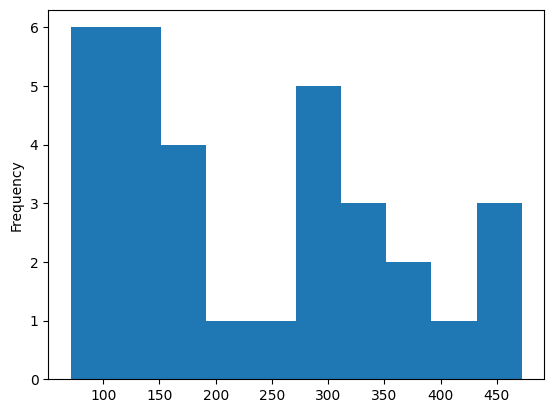

In [34]:
df.TotalSales.plot(kind = 'hist') #  built on top of bins
plt.show()

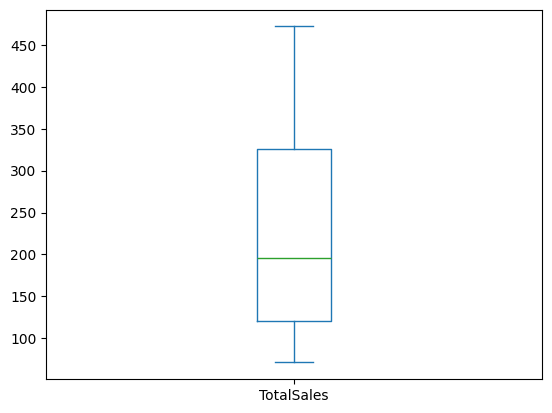

In [ ]:
df.TotalSales.plot(kind = 'box') #  built on top of bins
plt.show()

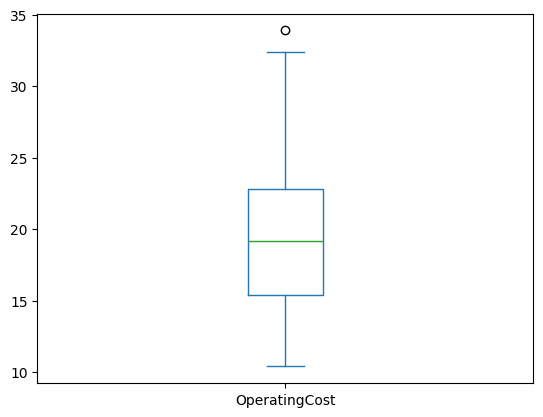

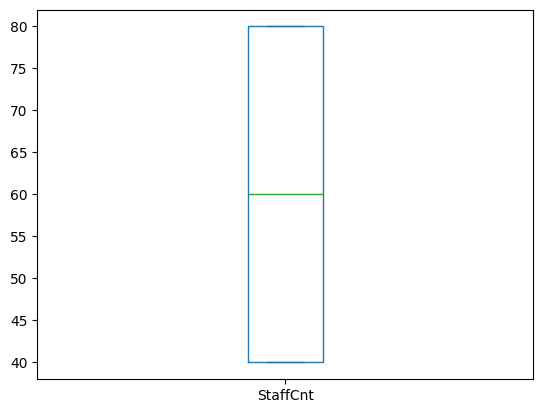

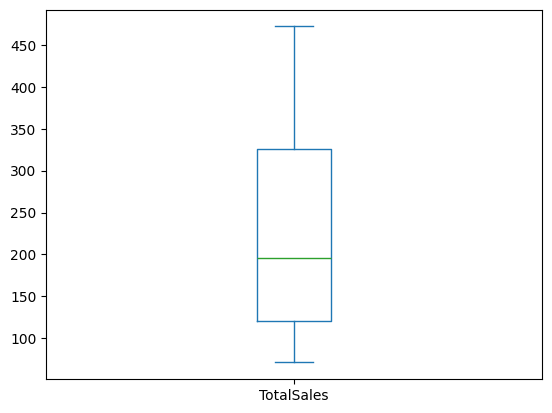

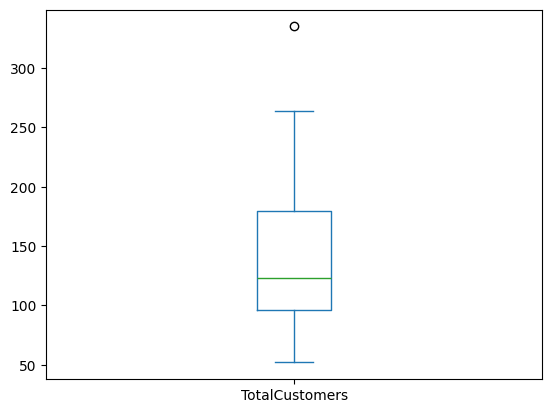

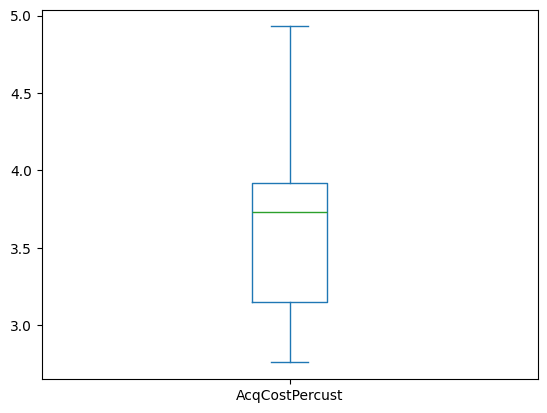

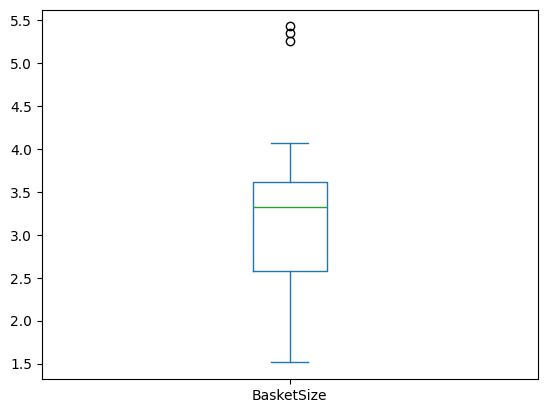

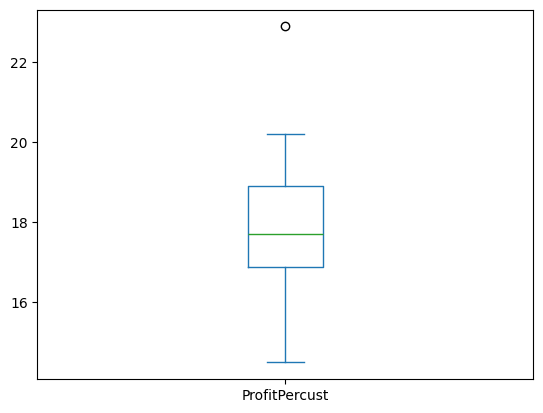

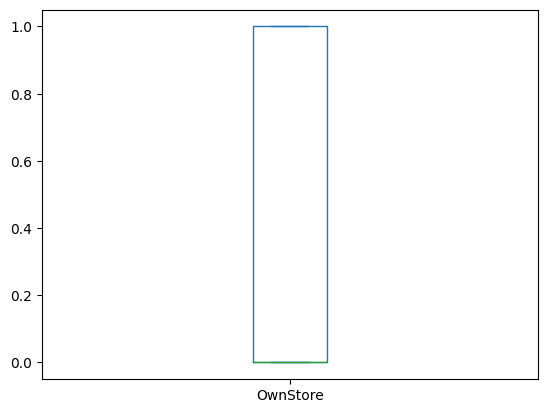

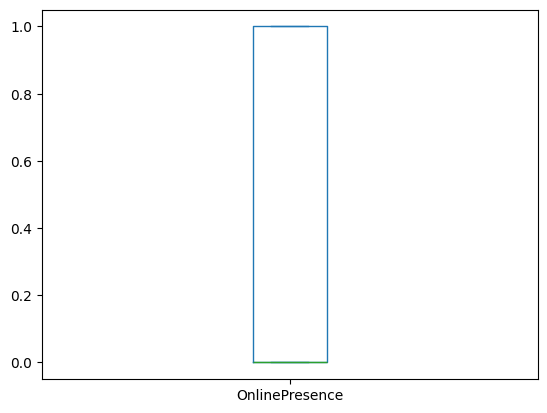

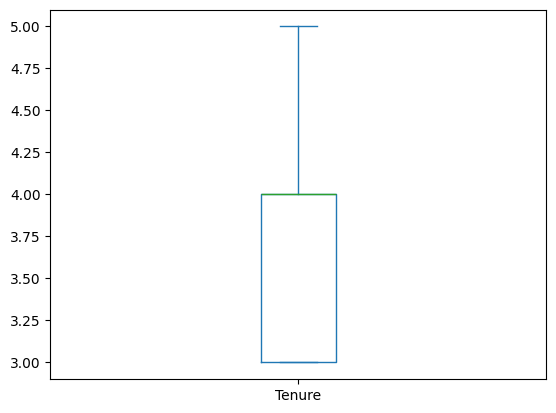

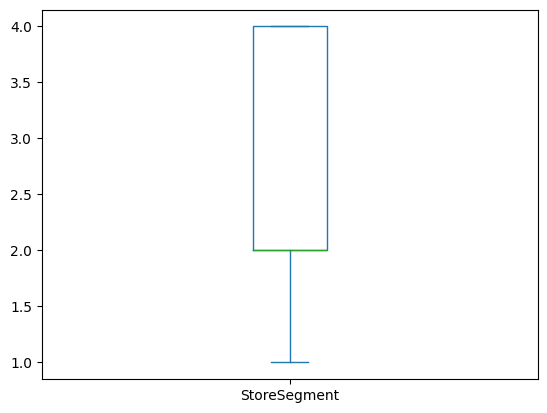

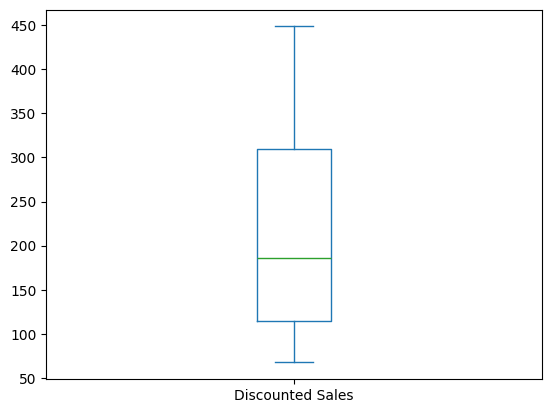

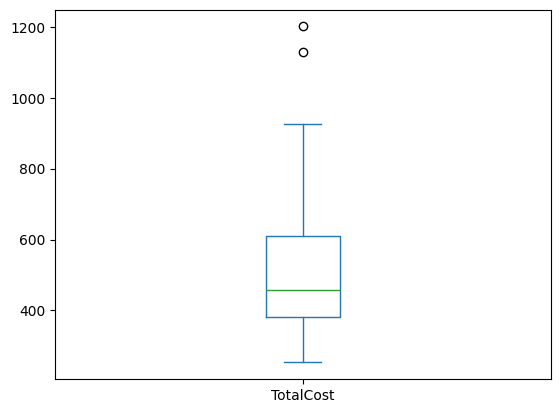

OperatingCost       None
StaffCnt            None
TotalSales          None
TotalCustomers      None
AcqCostPercust      None
BasketSize          None
ProfitPercust       None
OwnStore            None
OnlinePresence      None
Tenure              None
StoreSegment        None
Discounted Sales    None
TotalCost           None
dtype: object

In [36]:
# Build the box plot for all the numerical variables

def build_box(x):
    x.plot(kind = 'box') #  built on top of bins
    plt.show()

df.select_dtypes(['int', 'float']).apply(build_box)

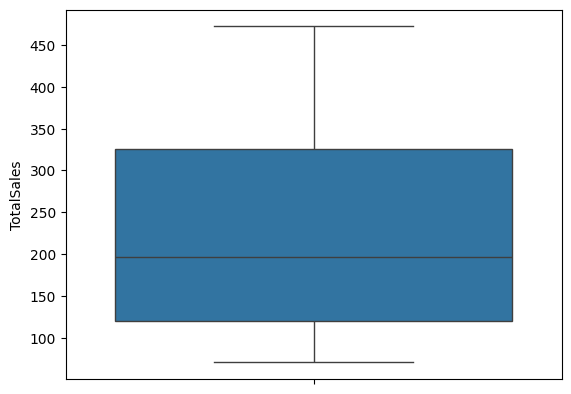

In [47]:
sns.boxplot(data=df, y='TotalSales')
plt.show()

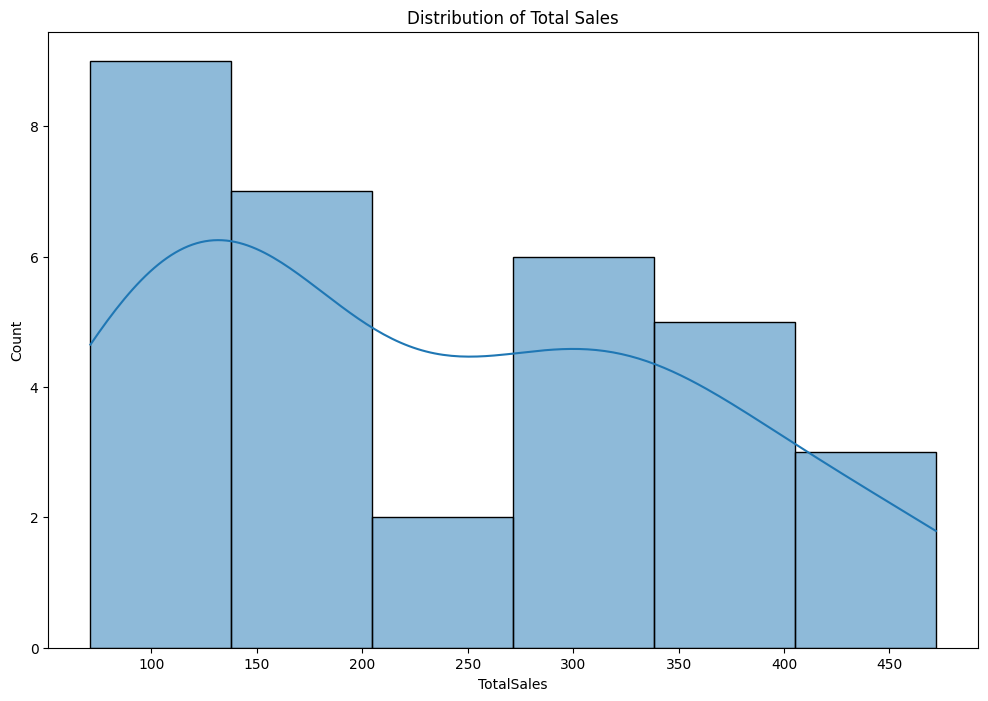

In [53]:
plt.figure(figsize=(12,8))
sns.histplot(data=df, x='TotalSales', kde=True)
plt.title('Distribution of Total Sales')
plt.show()

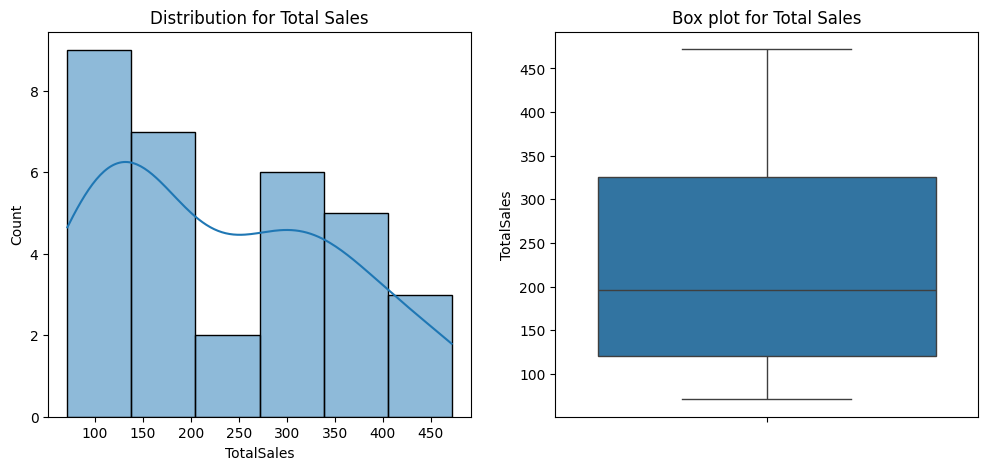

In [ ]:
# What should we to do give a single title to the whole canvas/frame? - Explore

fig, ax = plt.subplots(1, 2, figsize = (12, 5))
sns.histplot(data=df, x='TotalSales', kde=True, ax=ax[0])
ax[0].set_title('Distribution for Total Sales')
sns.boxplot(data=df, y='TotalSales', ax=ax[1])
ax[1].set_title('Box plot for Total Sales')
plt.show()

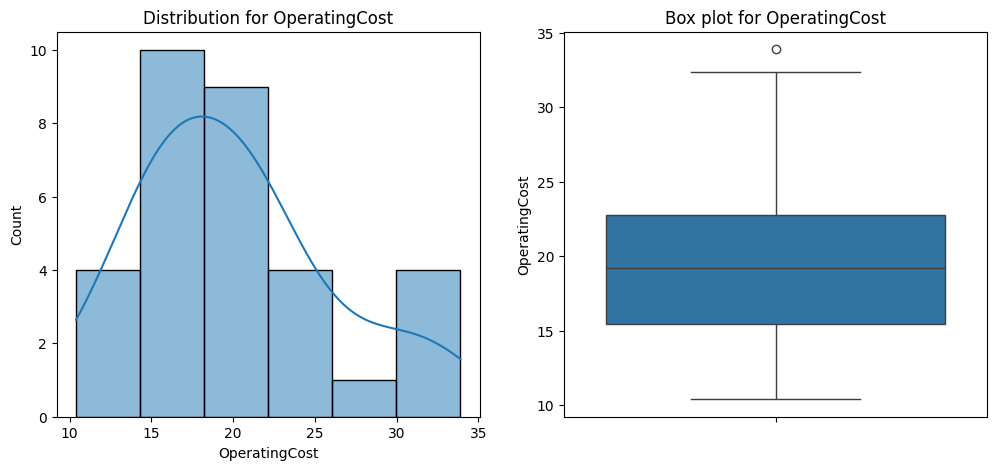

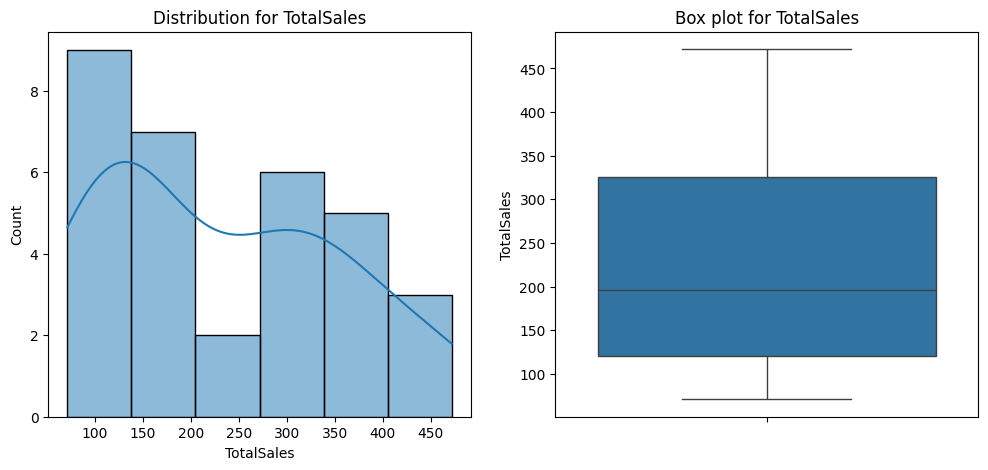

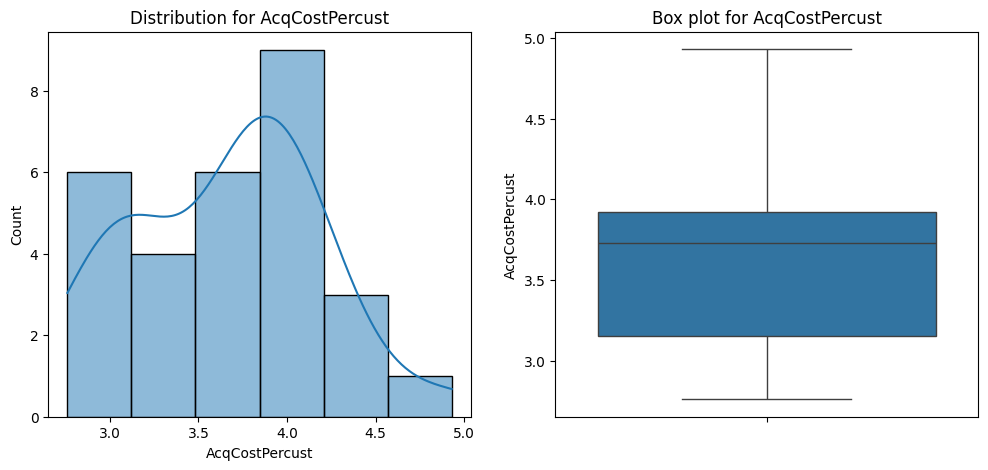

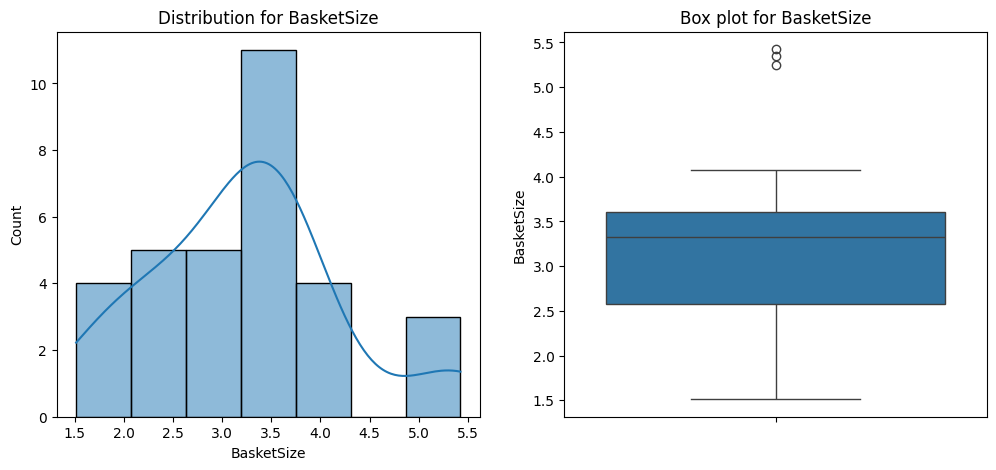

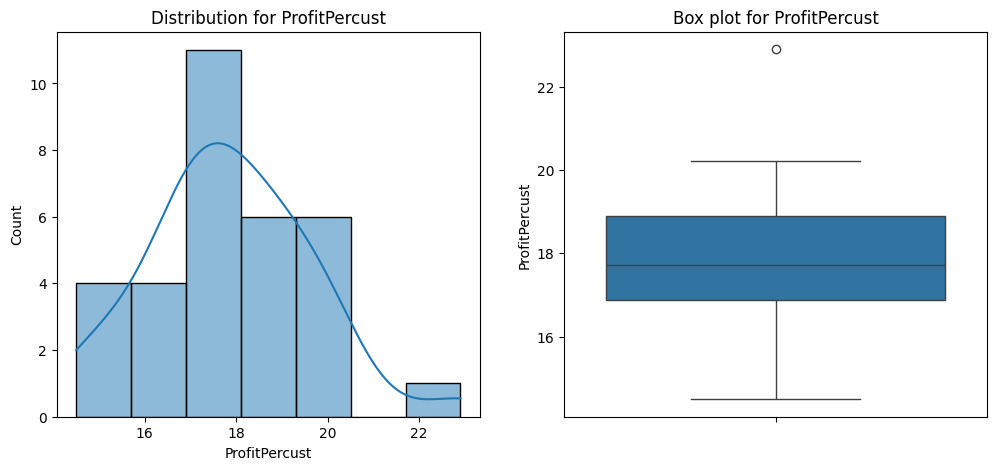

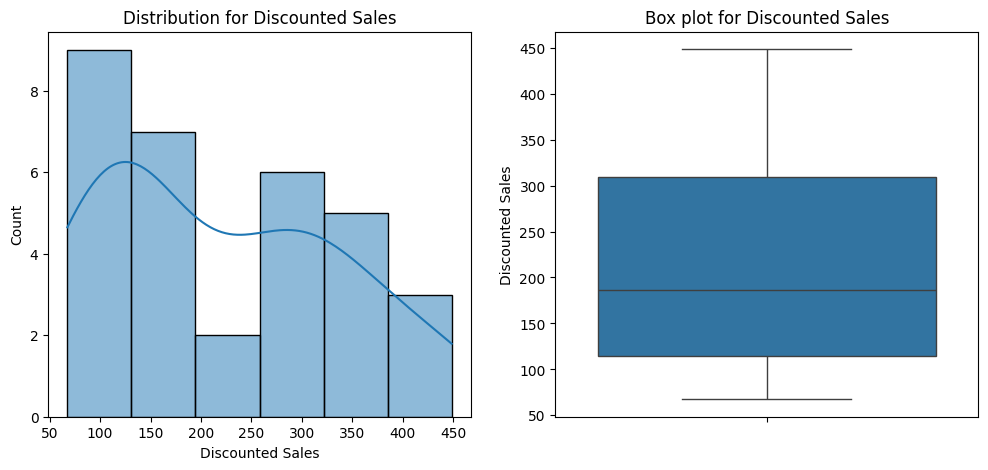

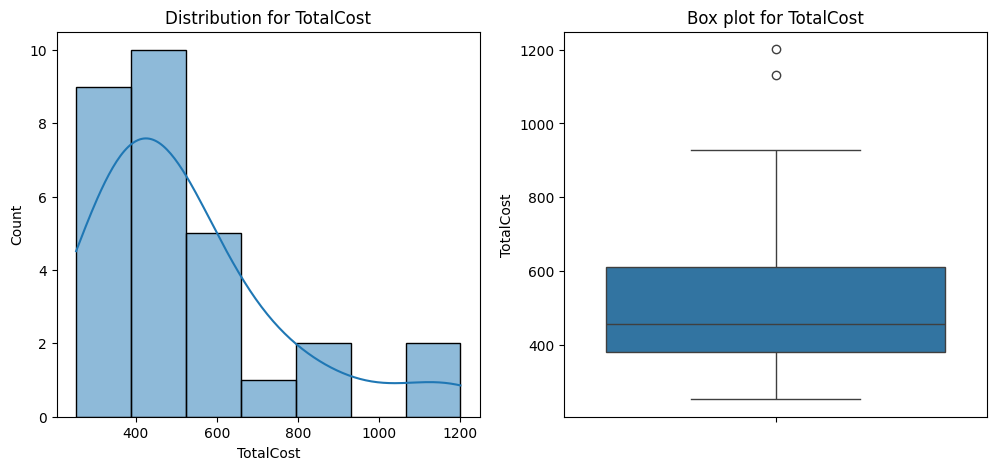

OperatingCost       None
TotalSales          None
AcqCostPercust      None
BasketSize          None
ProfitPercust       None
Discounted Sales    None
TotalCost           None
dtype: object

In [60]:
# Build the box plot + histogram in SBS fashion for all the numerical variables

def build_box(x):
    fig, ax = plt.subplots(1, 2, figsize = (12, 5))
    sns.histplot(x=x, kde=True, ax=ax[0])
    ax[0].set_title(f'Distribution for {x.name}')
    sns.boxplot(y = x, ax=ax[1])
    ax[1].set_title(f'Box plot for {x.name}')
    plt.show()

df.select_dtypes(['float']).apply(build_box)

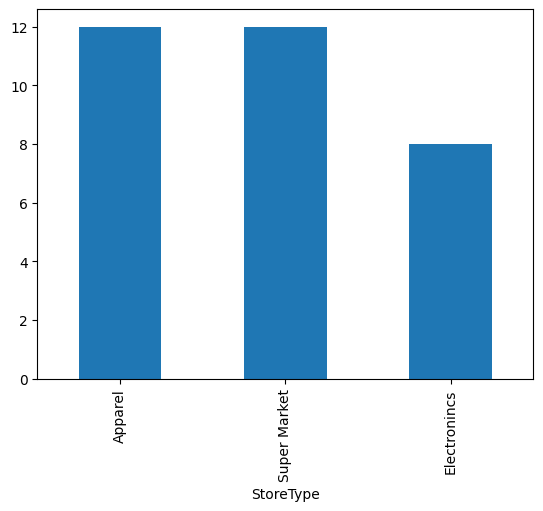

In [65]:
# Categorical data (Frequencies, count)
df.StoreType.value_counts().plot(kind='bar')
plt.show()

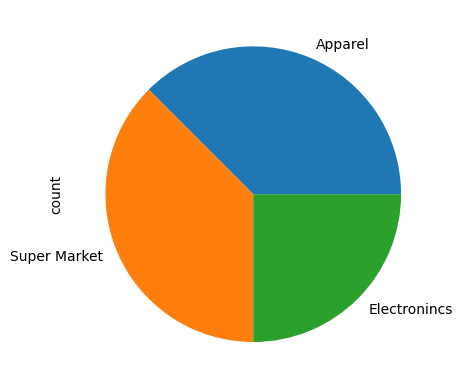

In [66]:
# Categorical data (Frequencies, count)
df.StoreType.value_counts().plot(kind='pie')
plt.show()

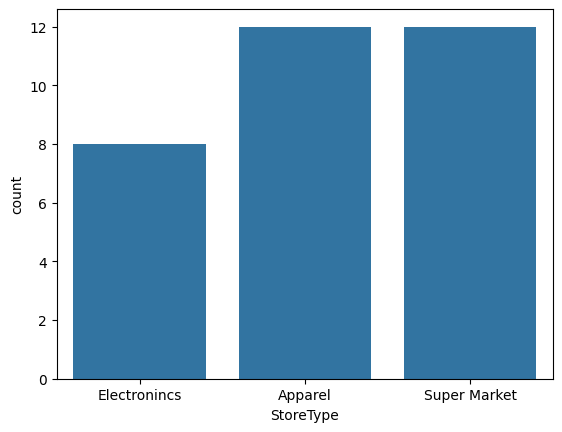

In [68]:
sns.countplot(data=df, x = 'StoreType')
plt.show()

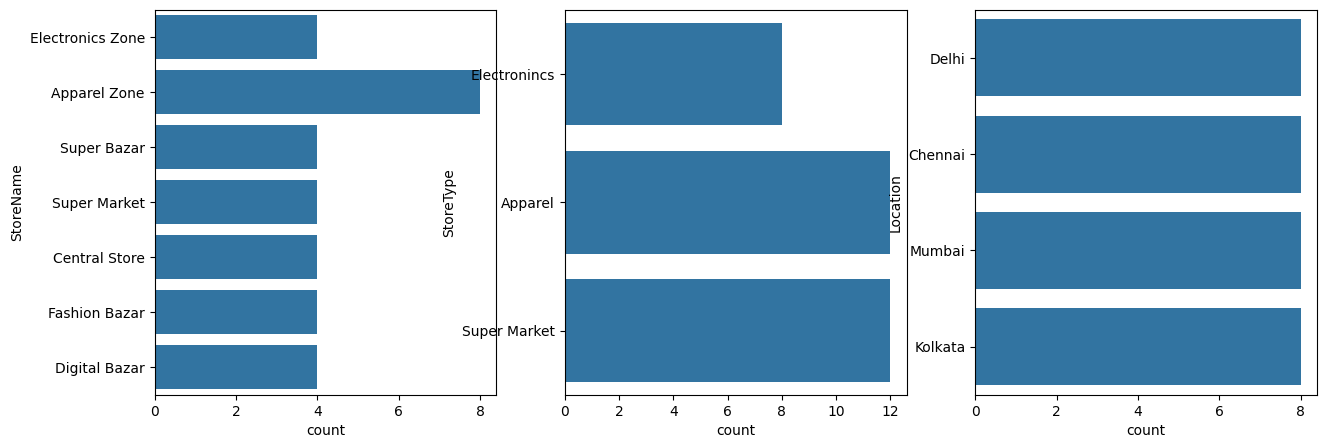

In [84]:
# Build the bar plot for all the categorical types (except store code) side by side.

fig, ax = plt.subplots(1, 3, figsize = (15, 5))

for idx, item in enumerate(['StoreName', 'StoreType', 'Location']):
    sns.countplot(data = df, y = item, ax = ax[idx]) # How to show the xlabels effiecintly for vertical bar chart
plt.show()

In [72]:
df.columns

Index(['StoreCode', 'StoreName', 'StoreType', 'Location', 'OperatingCost',
       'StaffCnt', 'TotalSales', 'TotalCustomers', 'AcqCostPercust',
       'BasketSize', 'ProfitPercust', 'OwnStore', 'OnlinePresence', 'Tenure',
       'StoreSegment', 'Discounted Sales', 'TotalCost'],
      dtype='object')